# N2 · dLLM vs 自回归 (AR): 双向 infilling 的胜利

> 配套 13.6-L2/L3 · 同一份回文数据, 训 dLLM 和 AR 两个模型。
> 对比: ① 都能生成合法序列, 但范式不同 ② **双向 infilling** —— 挖掉中间靠左的位 (镜像在右侧),
> dLLM 看双侧→准, AR 因果只看左侧→瞎猜。这是 dLLM 对 NLP 的核心价值。(接 9.4 对照实验)

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import diffusion_lm as dl
print('就绪')

就绪


## 1. 同数据训 dLLM 和 AR

In [2]:
torch.manual_seed(0)
data = dl.make_sequences(2000, seed=0)
dlm = dl.build_dlm(d_model=80); dl.train_dlm(dlm, data, epochs=800)
ar  = dl.build_ar(d_model=80);  dl.train_ar(ar, data, epochs=800)
gen_dlm = dl.generate_dlm(dlm, n=300, rounds=dl.L, seed=1)   # 足够轮数保质量
gen_ar  = dl.generate_ar(ar, n=300, seed=1)
print(f'dLLM 生成 (并行迭代, {dl.L}轮): 合法回文率 {dl.is_palindrome(gen_dlm):.2f}')
print(f'AR   生成 (左到右, {dl.L}步):   合法回文率 {dl.is_palindrome(gen_ar):.2f}')
print('→ 两者都能学会生成合法序列; 区别在"怎么生成"和"能不能双向填空"。')

dLLM 生成 (并行迭代, 6轮): 合法回文率 1.00
AR   生成 (左到右, 6步):   合法回文率 1.00
→ 两者都能学会生成合法序列; 区别在"怎么生成"和"能不能双向填空"。


## 2. 杀手锏: 双向 infilling
挖掉**位置 1** (它的镜像在位置 4, 在右侧)。要填对, 必须看**右侧**上下文:
- dLLM 双向 attention → 看得到位置 4 → 填对
- AR 因果 attention → 位置 1 只能看位置 0 → 看不到右侧 → 瞎猜

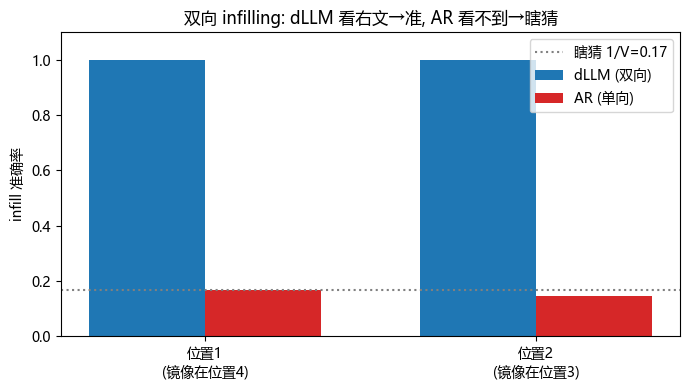

位置1: dLLM 1.00  AR 0.17
位置2: dLLM 1.00  AR 0.14
→ dLLM 双向上下文 = 天生会"完形填空"; AR 单向看不到右文。这是 dLLM 对可控/编辑类任务的核心优势。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
test = dl.make_sequences(400, seed=9)
accs, labels = [], []
for bp in [1, 2]:     # 两个"靠左、镜像在右"的位置
    a_dlm = dl.dlm_infill_accuracy(dlm, test, bp)
    a_ar  = dl.ar_infill_accuracy(ar, test, bp)
    accs.append((a_dlm, a_ar)); labels.append(f'位置{bp}\n(镜像在位置{dl.L-1-bp})')
import numpy as np
x = np.arange(len(labels)); w=0.35
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2, [a[0] for a in accs], w, label='dLLM (双向)', color='C0')
ax.bar(x+w/2, [a[1] for a in accs], w, label='AR (单向)', color='C3')
ax.axhline(1/dl.V, ls=':', color='gray', label=f'瞎猜 1/V={1/dl.V:.2f}')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('infill 准确率'); ax.set_ylim(0,1.1); ax.legend()
ax.set_title('双向 infilling: dLLM 看右文→准, AR 看不到→瞎猜')
plt.tight_layout(); plt.show()
for (ad,aa),lb in zip(accs,labels):
    print(f'{lb.split(chr(10))[0]}: dLLM {ad:.2f}  AR {aa:.2f}')
print('→ dLLM 双向上下文 = 天生会"完形填空"; AR 单向看不到右文。这是 dLLM 对可控/编辑类任务的核心优势。')

## 3. AR vs dLLM 范式对照表

In [4]:
print('''
┌─────────────┬──────────────────────┬──────────────────────────┐
│             │ 自回归 AR (主流 LLM)  │ 扩散 dLLM (LLaDA 等)      │
├─────────────┼──────────────────────┼──────────────────────────┤
│ 生成顺序    │ 左到右, 一次一个      │ 任意位, 按置信度并行迭代  │
│ 注意力      │ 因果(单向)            │ 双向                      │
│ 步数        │ = 序列长度 L          │ T 轮 (可 < L, 质量换并行) │
│ infilling   │ 弱(只看左文)          │ 强(看左右全文)            │
│ 可控/编辑   │ 较难                  │ 较易(双向+任意位)         │
│ 成熟度      │ 极成熟(生态/工具全)   │ 新兴(2025-2026 热点)      │
└─────────────┴──────────────────────┴──────────────────────────┘''')


┌─────────────┬──────────────────────┬──────────────────────────┐
│             │ 自回归 AR (主流 LLM)  │ 扩散 dLLM (LLaDA 等)      │
├─────────────┼──────────────────────┼──────────────────────────┤
│ 生成顺序    │ 左到右, 一次一个      │ 任意位, 按置信度并行迭代  │
│ 注意力      │ 因果(单向)            │ 双向                      │
│ 步数        │ = 序列长度 L          │ T 轮 (可 < L, 质量换并行) │
│ infilling   │ 弱(只看左文)          │ 强(看左右全文)            │
│ 可控/编辑   │ 较难                  │ 较易(双向+任意位)         │
│ 成熟度      │ 极成熟(生态/工具全)   │ 新兴(2025-2026 热点)      │
└─────────────┴──────────────────────┴──────────────────────────┘


## 4. 反思 (13.6 收口)

你在同一份数据上对比了 dLLM 和 AR, 看清了 dLLM 对 NLP 的价值。带走:
- **范式差异**: AR 左到右因果; dLLM 任意位并行 + 双向。机制都是 transformer, 只换「生成范式」。
- **dLLM 杀手锏**: 双向 infilling / 可控编辑 (本 notebook 实测 dLLM 准、AR 瞎猜)。
- **代价**: 并行度 vs 质量旋钮 (N1); 生态远不如 AR 成熟 (开放问题, 用 M9.3 批判读)。
- 为什么你 NLP 人该关注: dLLM 是 AR 之外的另一条生成范式, 在并行解码/可控生成上有结构性优势。

> **M13.6 收口**: 生成式媒体绕一圈回 NLP —— 文本也能扩散, dLLM = transformer + 离散扩散范式。
> **交棒 M13.7「generative-media-graduation」**: capstone, 把 M13 全链 (扩散→流→DiT→视频→世界模型→dLLM) 装配起来 + 找研究 gap。下一专题 `generative-media-graduation`。